# 03 — `ativo_total`/`credito_total`: volatilidade da série e a hipótese das agências

Extensão pontual do `01_eda_painel_2015_2025.ipynb`: durante a univariada, `ativo_total` e `credito_total` apareceram cruzados com o câmbio nos meses de outlier (ver seção correspondente no notebook 01). Este notebook formaliza três coisas que o 01 só apontou, sem confirmar:

1. **Confirmar o padrão** — existe mesmo uma mudança relevante em `ativo_total`/`credito_total`, ou é impressão da tabela de outliers? (Spoiler: existe, mas não é o que a gente esperava — não é uma quebra pontual em 2019-2020, é uma volatilidade estrutural que a série tem o tempo todo.)
2. **Testar a hipótese das agências** — o fechamento de agências bancárias físicas em Santos (mesma fonte, ESTBAN) explica esse padrão?
3. **Documentar a anomalia de 2025** — a série de agências tem um problema de qualidade de dado nesse ano, registrado aqui como limitação, sem tentar resolver.


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display, Markdown

painel = pd.read_csv('https://raw.githubusercontent.com/vicleme/port-of-santos-credit-fx/refs/heads/main/data/processed/painel_2015_2025.csv')
agencias = pd.read_csv('https://raw.githubusercontent.com/vicleme/port-of-santos-credit-fx/refs/heads/main/data/raw/estban_agencias_santos_2015-2025.csv')
agencias_por_banco_2025 = pd.read_csv('https://raw.githubusercontent.com/vicleme/port-of-santos-credit-fx/refs/heads/main/data/raw/estban_agencias_santos_2025_por_banco.csv')

painel.head(2)

,ano,mes,cambio_venda,ativo_total,credito_emprestimos_titulos,credito_financiamentos,credito_outras_operacoes,credito_total,passivo_total,exportação_fob,importação_fob,exportação_kg,importação_kg
0,2015,1,2.6623,3.483431e+10,2.571444e+09,304829194.0,78318169.0,1.002071e+10,3.483431e+10,3.559136e+09,4.610173e+09,4.703620e+09,1.970297e+09
1,2015,2,2.8782,3.293911e+10,2.571864e+09,306515589.0,77453579.0,7.849779e+09,3.293911e+10,3.151947e+09,3.918598e+09,2.776368e+09,1.637549e+09


## 1. Confirmando o padrão em `ativo_total`/`credito_total`

O notebook 01 mostrou que `ativo_total` e `credito_total` sobem/caem juntos e aparecem cruzados com câmbio nos meses de outlier — mas isso foi lido direto da tabela de outliers (que usa o IQR do período inteiro), não de uma visão temporal. Aqui olhamos a evolução ano a ano de verdade — inclusive pra checar se a hipótese inicial de uma "quebra pontual em 2019-2020" é mesmo o achado certo.


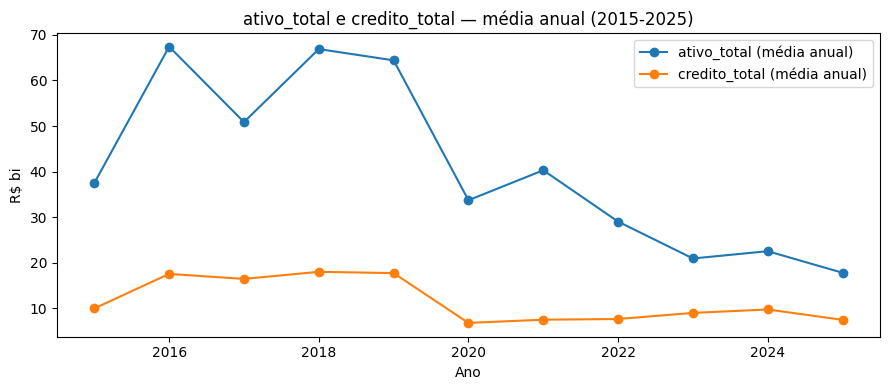

In [ ]:
anual = painel.groupby('ano')[['ativo_total', 'credito_total']].mean()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(anual.index, anual['ativo_total'] / 1e9, marker='o', label='ativo_total (média anual)')
ax.plot(anual.index, anual['credito_total'] / 1e9, marker='o', label='credito_total (média anual)')
ax.set_ylabel('R$ bi')
ax.set_xlabel('Ano')
ax.set_title('ativo_total e credito_total — média anual (2015-2025)')
ax.legend()
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, pos: f'{v:,.0f}'.replace(',', '.')))
plt.tight_layout()
plt.show()

In [ ]:
ativo_2019 = anual.loc[2019, 'ativo_total']
ativo_2020 = anual.loc[2020, 'ativo_total']
credito_2019 = anual.loc[2019, 'credito_total']
credito_2020 = anual.loc[2020, 'credito_total']

queda_ativo = (1 - ativo_2020 / ativo_2019) * 100
queda_credito = (1 - credito_2020 / credito_2019) * 100

variacoes = anual['ativo_total'].pct_change().drop(2020) * 100
maior_alta = variacoes.max()
maior_queda_fora_2020 = variacoes.min()

texto = (
    f"**ativo_total**: {ativo_2019/1e9:,.1f} bi (2019) → {ativo_2020/1e9:,.1f} bi (2020), "
    f"queda de **{queda_ativo:.0f}%** num ano só — a maior queda anual de toda a série.\n\n"
    f"**credito_total**: {credito_2019/1e9:,.1f} bi (2019) → {credito_2020/1e9:,.1f} bi (2020), "
    f"queda de **{queda_credito:.0f}%** num ano só.\n\n"
    f"**Mas atenção pra moldura certa**: a série inteira é volátil, não só em 2019-2020. A variação "
    f"ano a ano de `ativo_total` no resto da série vai de {maior_queda_fora_2020:.0f}% até "
    f"**+{maior_alta:.0f}%** (2016) — ou seja, há uma alta anual maior, em módulo, que a própria queda "
    f"de 2020. A queda de {queda_ativo:.0f}% em 2020 é real e é a maior queda de um ano só em toda a "
    f"série, mas **não é uma anomalia isolada** — é a maior de várias oscilações grandes que essa série "
    f"tem o tempo todo (2022 e 2023 também caem ~28% cada). A pergunta certa não é 'o que quebrou em "
    f"2019-2020', e sim 'por que essa série é estruturalmente volátil' — o que enfraquece ainda mais a "
    f"hipótese de que um fator gradual e monotônico como fechamento de agências explique o padrão."
)
display(Markdown(texto))


**ativo_total**: 64.4 bi (2019) → 33.7 bi (2020), queda de **48%** num ano só — a maior queda anual de toda a série.

**credito_total**: 17.8 bi (2019) → 6.8 bi (2020), queda de **62%** num ano só.

**Mas atenção pra moldura certa**: a série inteira é volátil, não só em 2019-2020. A variação ano a ano de `ativo_total` no resto da série vai de -28% até **+80%** (2016) — ou seja, há uma alta anual maior, em módulo, que a própria queda de 2020. A queda de 48% em 2020 é real e é a maior queda de um ano só em toda a série, mas **não é uma anomalia isolada** — é a maior de várias oscilações grandes que essa série tem o tempo todo (2022 e 2023 também caem ~28% cada). A pergunta certa não é 'o que quebrou em 2019-2020', e sim 'por que essa série é estruturalmente volátil' — o que enfraquece ainda mais a hipótese de que um fator gradual e monotônico como fechamento de agências explique o padrão.

## 2. Testando a hipótese das agências

A hipótese: parte da queda vem do fechamento de agências bancárias físicas em Santos — o `ativo_total`/`credito_total` do ESTBAN soma o balanço das agências *sediadas no município*, então se um banco fecha sua agência em Santos (mesmo mantendo crédito às empresas por canais digitais ou agência em outra praça), o número reportado para Santos cai, sem que isso signifique necessariamente uma contração real da atividade econômica local.

A série de agências abaixo é a soma de `agencias_processadas` de todos os bancos com agência em Santos, por mês — deduplicada por banco. Cada banco reporta um único valor de `agencias_processadas` por mês, repetido em todos os verbetes (uma linha por verbete contábil); somar direto sem tratar isso duplicaria o valor várias vezes, então a query de origem usa um `DISTINCT` por (ano, mês, banco) antes do `SUM`.

**Recorte usado nesta seção: 2015-2024.** 2025 é tratado separadamente na seção 3 — a série tem uma anomalia de qualidade de dado que precisa ser resolvida antes de entrar em qualquer correlação.

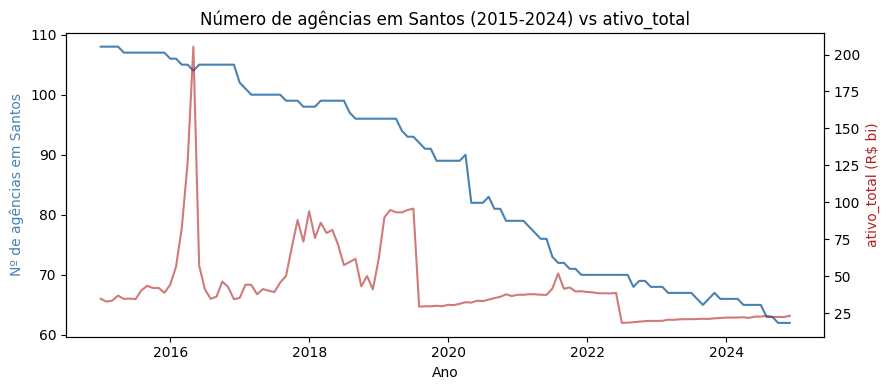

In [ ]:
agencias_confiavel = agencias[agencias['ano'] <= 2024].copy()

fig, ax1 = plt.subplots(figsize=(9, 4))
ax1.plot(agencias_confiavel['ano'] + (agencias_confiavel['mes'] - 1) / 12,
         agencias_confiavel['total_agencias_santos'], color='steelblue')
ax1.set_ylabel('Nº de agências em Santos', color='steelblue')
ax1.set_xlabel('Ano')
ax1.set_title('Número de agências em Santos (2015-2024) vs ativo_total')

ax2 = ax1.twinx()
painel_2024 = painel[painel['ano'] <= 2024]
ax2.plot(painel_2024['ano'] + (painel_2024['mes'] - 1) / 12,
         painel_2024['ativo_total'] / 1e9, color='firebrick', alpha=0.6)
ax2.set_ylabel('ativo_total (R$ bi)', color='firebrick')

plt.tight_layout()
plt.show()

In [ ]:
# junta agências com o painel pra calcular a correlação de verdade
base_corr = agencias_confiavel.merge(painel, on=['ano', 'mes'], how='inner')
corr_ativo = base_corr['total_agencias_santos'].corr(base_corr['ativo_total'])
corr_credito = base_corr['total_agencias_santos'].corr(base_corr['credito_total'])

agencias_anual = agencias_confiavel.groupby('ano')['total_agencias_santos'].mean()
queda_agencias_total = (1 - agencias_anual.loc[2024] / agencias_anual.loc[2015]) * 100

texto = (
    f"Correlação (2015-2024, mensal): **{corr_ativo:.2f}** entre nº de agências e `ativo_total`; "
    f"**{corr_credito:.2f}** entre nº de agências e `credito_total`. Positiva, mas moderada — não é "
    f"forte o suficiente pra sozinha carregar a explicação do padrão.\n\n"
    f"O motivo aparece no formato das duas séries: o número de agências caiu {queda_agencias_total:.0f}% "
    f"entre 2015 e 2024 de forma **suave e monotônica** (~2 agências por ano, sem nenhuma reversão), "
    f"enquanto `ativo_total` é **volátil pra cima e pra baixo o tempo todo** (visto na seção 1: alta de "
    f"+80% em 2016, quedas de ~28% em 2022 e 2023, além da queda de 2020). Uma série que só desce "
    f"devagar não consegue explicar oscilações grandes em ambas as direções.\n\n"
    f"**Conclusão desta seção:** o fechamento de agências é um fator estrutural real, coerente com a "
    f"tendência de queda de longo prazo de `ativo_total`/`credito_total` — mas explica só uma fração "
    f"pequena e constante da queda, não a volatilidade ano a ano. A causa da volatilidade em si (por que "
    f"`ativo_total` sobe 80% num ano e cai 28% em outros) segue sem explicação; fica registrada como "
    f"pergunta em aberto pro grupo, não resolvida aqui."
)
display(Markdown(texto))


Correlação (2015-2024, mensal): **0.50** entre nº de agências e `ativo_total`; **0.52** entre nº de agências e `credito_total`. Positiva, mas moderada — não é forte o suficiente pra sozinha carregar a explicação do padrão.

O motivo aparece no formato das duas séries: o número de agências caiu 40% entre 2015 e 2024 de forma **suave e monotônica** (~2 agências por ano, sem nenhuma reversão), enquanto `ativo_total` é **volátil pra cima e pra baixo o tempo todo** (visto na seção 1: alta de +80% em 2016, quedas de ~28% em 2022 e 2023, além da queda de 2020). Uma série que só desce devagar não consegue explicar oscilações grandes em ambas as direções.

**Conclusão desta seção:** o fechamento de agências é um fator estrutural real, coerente com a tendência de queda de longo prazo de `ativo_total`/`credito_total` — mas explica só uma fração pequena e constante da queda, não a volatilidade ano a ano. A causa da volatilidade em si (por que `ativo_total` sobe 80% num ano e cai 28% em outros) segue sem explicação; fica registrada como pergunta em aberto pro grupo, não resolvida aqui.

## 3. Anomalia de qualidade de dado em 2025 (limitação, não resolvida)

Ao estender a série de agências pra 2025, o total mensal ficou instável de um jeito que não faz sentido econômico (35 agências em março, 59 em junho, 47 em julho — banco não fecha e reabre agência inteira mês a mês). Abrindo por banco, o padrão fica claro: não é queda real, é **buraco de reporte pontual por instituição**.

In [ ]:
pivot = agencias_por_banco_2025.pivot(index='instituicao', columns='mes', values='agencias_processadas')
pivot.columns = [f'mes_{m:02d}' for m in pivot.columns]
pivot

,mes_02,mes_03,mes_04,mes_05,mes_06,mes_07,mes_08
instituicao,,,,,,,
BCO BRADESCO S.A.,9,9,9,9,9,9,9
BCO CITIBANK S.A.,1,1,1,1,1,1,1
BCO DO BRASIL S.A.,12,12,12,12,12,0,12
BCO SAFRA S.A.,1,1,1,1,1,1,1
BCO SANTANDER (BRASIL) S.A.,18,0,0,17,15,15,15
CAIXA ECONOMICA FEDERAL,12,12,12,12,12,12,12
ITAÚ UNIBANCO S.A.,0,0,0,0,9,9,9


In [ ]:
zeros_suspeitos = agencias_por_banco_2025[agencias_por_banco_2025['agencias_processadas'] == 0]
bancos_com_buraco = zeros_suspeitos['instituicao'].unique()

texto = (
    f"**{len(bancos_com_buraco)} bancos** têm pelo menos um mês zerado em 2025, cada um numa janela "
    f"diferente: {', '.join(bancos_com_buraco)}. Nenhum desses bancos é pequeno o suficiente pra zerar "
    f"fisicamente todas as agências de uma praça como Santos por 2-4 meses e depois voltar ao normal — "
    f"é o padrão característico de um buraco de ingestão/consolidação do dado (no ESTBAN original ou no "
    f"pipeline da Base dos Dados), não um evento econômico real.\n\n"
    f"**Tratamento recomendado, ainda não aplicado:** tratar `agencias_processadas == 0` como ausente (NaN) "
    f"nesses meses/bancos específicos, e então decidir — interpolar, excluir o mês do total, ou excluir 2025 "
    f"inteiro de qualquer análise que use a série de agências — antes de usar esse ano em conjunto com "
    f"`ativo_total`/`credito_total`. **A série de agências é confiável de 2015 a 2024; 2025 não é, sem esse "
    f"tratamento.**"
)
display(Markdown(texto))


**3 bancos** têm pelo menos um mês zerado em 2025, cada um numa janela diferente: BCO DO BRASIL S.A., ITAÚ UNIBANCO S.A., BCO SANTANDER (BRASIL) S.A.. Nenhum desses bancos é pequeno o suficiente pra zerar fisicamente todas as agências de uma praça como Santos por 2-4 meses e depois voltar ao normal — é o padrão característico de um buraco de ingestão/consolidação do dado (no ESTBAN original ou no pipeline da Base dos Dados), não um evento econômico real.

**Tratamento recomendado, ainda não aplicado:** tratar `agencias_processadas == 0` como ausente (NaN) nesses meses/bancos específicos, e então decidir — interpolar, excluir o mês do total, ou excluir 2025 inteiro de qualquer análise que use a série de agências — antes de usar esse ano em conjunto com `ativo_total`/`credito_total`. **A série de agências é confiável de 2015 a 2024; 2025 não é, sem esse tratamento.**

## Resumo da investigação

- `ativo_total`/`credito_total` **não têm uma quebra pontual isolada em 2019-2020** — essa era a hipótese inicial, mas os dados não sustentam. O que existe, de fato, é uma **volatilidade estrutural** ao longo de toda a série: altas de até +80% num ano (2016) e quedas de até -48% (2020), -28% (2022, 2023). 2020 é a maior queda anual, mas não é isolada — é a mais extrema de várias oscilações grandes.
- O fechamento de agências bancárias em Santos é um fator estrutural real e correlacionado (correlação moderada, ~0,50), mas seu padrão é **suave e monotônico** — não consegue explicar uma série que oscila com essa intensidade em ambas as direções. Explica uma fração pequena e constante da queda de longo prazo, não a volatilidade.
- A causa real da volatilidade ano a ano segue **sem explicação** — fica como pergunta em aberto pro grupo.
- A série de agências tem um problema de qualidade de dado em 2025 (buracos de reporte por banco) que precisa ser tratado antes de ser usada — registrado aqui, não resolvido.
